In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(palette="colorblind")

import warnings
warnings.filterwarnings('ignore')

# Parsing dates

In [2]:
df = pd.read_csv("aus_retail.csv")
df.head()

,Date,Region,Sector,Turnover
0,1982-04-01,New South Wales,Supermarket and grocery stores,303.1
1,1982-05-01,New South Wales,Supermarket and grocery stores,297.8
2,1982-06-01,New South Wales,Supermarket and grocery stores,298.0
3,1982-07-01,New South Wales,Supermarket and grocery stores,307.9
4,1982-08-01,New South Wales,Supermarket and grocery stores,299.2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84105 entries, 0 to 84104
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      84105 non-null  object 
 1   Region    84105 non-null  object 
 2   Sector    84105 non-null  object 
 3   Turnover  77951 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.6+ MB


In [4]:
df = pd.read_csv("aus_retail.csv", parse_dates=["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84105 entries, 0 to 84104
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      84105 non-null  datetime64[ns]
 1   Region    84105 non-null  object        
 2   Sector    84105 non-null  object        
 3   Turnover  77951 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.6+ MB


In [5]:
df = pd.read_csv("aus_retail.csv", parse_dates=["Date"], date_format="%Y-%m-%d")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84105 entries, 0 to 84104
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      84105 non-null  datetime64[ns]
 1   Region    84105 non-null  object        
 2   Sector    84105 non-null  object        
 3   Turnover  77951 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.6+ MB


In [6]:
df = pd.read_csv("aus_retail.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84105 entries, 0 to 84104
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      84105 non-null  datetime64[ns]
 1   Region    84105 non-null  object        
 2   Sector    84105 non-null  object        
 3   Turnover  77951 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.6+ MB


# Setting the index

In [7]:
df = df.set_index("Date")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 84105 entries, 1982-04-01 to 2019-04-01
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Region    84105 non-null  object 
 1   Sector    84105 non-null  object 
 2   Turnover  77951 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.6+ MB


# Plotting series

In [8]:
df["Region"].unique()

array(['New South Wales', 'Victoria', 'Queensland', 'South Australia',
       'Western Australia', 'Tasmania', 'Northern Territory',
       'Australian Capital Territory', 'Total (State)'], dtype=object)

In [9]:
df["Sector"].unique()

array(['Supermarket and grocery stores', 'Liquor retailing',
       'Other specialised food retailing', 'Food retailing',
       'Furniture, floor coverings, houseware and textile goods retailing',
       'Electrical and electronic goods retailing',
       'Hardware, building and garden supplies retailing',
       'Household goods retailing', 'Clothing retailing',
       'Footwear and other personal accessory retailing',
       'Clothing, footwear and personal accessory retailing',
       'Department stores', 'Newspaper and book retailing',
       'Other recreational goods retailing',
       'Pharmaceutical, cosmetic and toiletry goods retailing',
       'Other retailing n.e.c.', 'Other retailing',
       'Cafes, restaurants and catering services',
       'Takeaway food services',
       'Cafes, restaurants and takeaway food services',
       'Total (Industry)'], dtype=object)

In [10]:
df1 = df[(df["Region"] == "Queensland") & (df["Sector"] == "Food retailing")]
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 445 entries, 1982-04-01 to 2019-04-01
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Region    445 non-null    object 
 1   Sector    445 non-null    object 
 2   Turnover  445 non-null    float64
dtypes: float64(1), object(2)
memory usage: 13.9+ KB


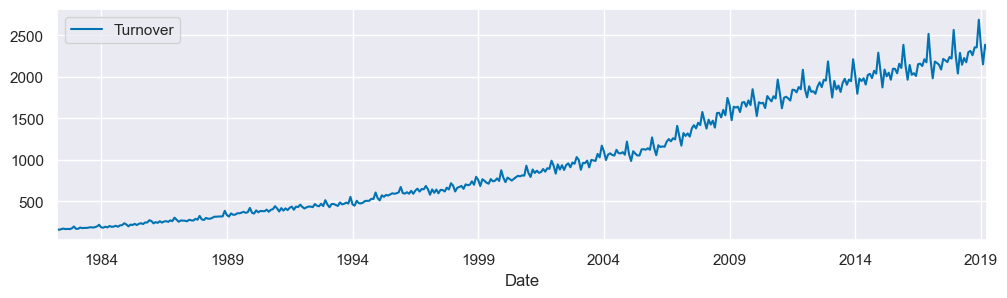

In [11]:
_ = df1.plot(figsize=(12,3))

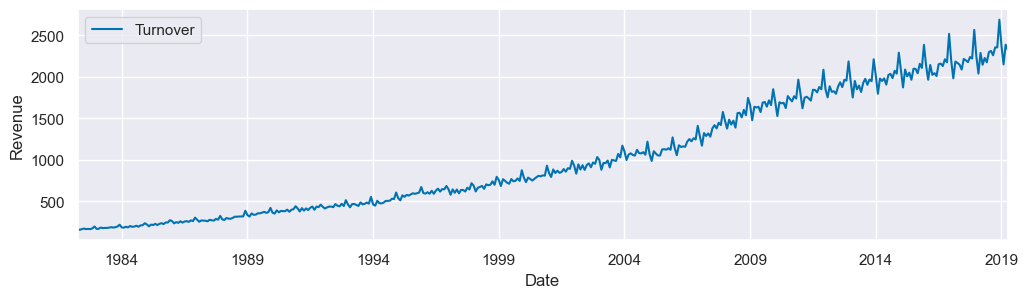

In [12]:
_ = df1.plot(figsize=(12,3), kind="line", grid=True, ylabel="Revenue")

# Date range

In [13]:
dates = pd.date_range(start='2021-01-01', periods=3, freq='D')
dates

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03'], dtype='datetime64[ns]', freq='D')

In [14]:
pd.date_range(start='2021-01-01', periods=5, freq='ME')

DatetimeIndex(['2021-01-31', '2021-02-28', '2021-03-31', '2021-04-30',
               '2021-05-31'],
              dtype='datetime64[ns]', freq='ME')

In [15]:
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
sales = np.random.normal(loc=10, scale=3, size=dates.size)
df = pd.DataFrame({"sales": sales}, index=dates)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2025-01-01 to 2025-12-31
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


<Axes: >

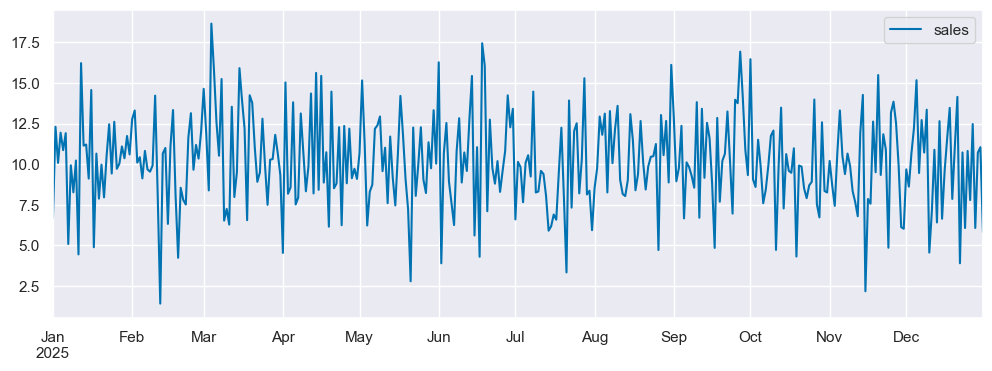

In [16]:
df.plot(figsize=(12,4))

# Attributes extracted from dates

In [17]:
df["day_of_week"] = df.index.day_name()
df.head()

,sales,day_of_week
2025-01-01,6.686478,Wednesday
2025-01-02,12.305099,Thursday
2025-01-03,10.080314,Friday
2025-01-04,11.940293,Saturday
2025-01-05,10.865487,Sunday


In [18]:
df["quarter"] = df.index.quarter
df.head()

,sales,day_of_week,quarter
2025-01-01,6.686478,Wednesday,1
2025-01-02,12.305099,Thursday,1
2025-01-03,10.080314,Friday,1
2025-01-04,11.940293,Saturday,1
2025-01-05,10.865487,Sunday,1


In [19]:
df["day"] = df.index.day
df["month"] = df.index.month
df["year"] = df.index.year
df.head()

,sales,day_of_week,quarter,day,month,year
2025-01-01,6.686478,Wednesday,1,1,1,2025
2025-01-02,12.305099,Thursday,1,2,1,2025
2025-01-03,10.080314,Friday,1,3,1,2025
2025-01-04,11.940293,Saturday,1,4,1,2025
2025-01-05,10.865487,Sunday,1,5,1,2025


# Timedelta in Pandas

In [20]:
df['delivery_date'] = df.index + pd.Timedelta(days=14)
df['delivery_day_of_week'] = df['delivery_date'].dt.day_name()
df.head()

,sales,day_of_week,quarter,day,month,year,delivery_date,delivery_day_of_week
2025-01-01,6.686478,Wednesday,1,1,1,2025,2025-01-15,Wednesday
2025-01-02,12.305099,Thursday,1,2,1,2025,2025-01-16,Thursday
2025-01-03,10.080314,Friday,1,3,1,2025,2025-01-17,Friday
2025-01-04,11.940293,Saturday,1,4,1,2025,2025-01-18,Saturday
2025-01-05,10.865487,Sunday,1,5,1,2025,2025-01-19,Sunday


# Offsets

In [21]:
df['BD_delivery_date'] = df.index + pd.offsets.BDay(14)
df['BD_delivery_day_of_week'] = df['BD_delivery_date'].dt.day_name()
df.head()

,sales,day_of_week,quarter,day,month,year,delivery_date,delivery_day_of_week,BD_delivery_date,BD_delivery_day_of_week
2025-01-01,6.686478,Wednesday,1,1,1,2025,2025-01-15,Wednesday,2025-01-21,Tuesday
2025-01-02,12.305099,Thursday,1,2,1,2025,2025-01-16,Thursday,2025-01-22,Wednesday
2025-01-03,10.080314,Friday,1,3,1,2025,2025-01-17,Friday,2025-01-23,Thursday
2025-01-04,11.940293,Saturday,1,4,1,2025,2025-01-18,Saturday,2025-01-23,Thursday
2025-01-05,10.865487,Sunday,1,5,1,2025,2025-01-19,Sunday,2025-01-23,Thursday


In [22]:
df["BD_delivery_day_of_week"].unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Monday'],
      dtype=object)

In [23]:
df["BD_delivery_date"].unique().size

261

In [24]:
uk_holidays = ['2025-01-01', '2025-04-18', '2025-04-21', '2025-05-05',
                '2025-05-26', '2025-08-25', '2025-12-25', '2025-12-26']

df['BD_delivery_date_no_hols'] = df.index + pd.offsets.CustomBusinessDay(n=14,
                                                          holidays=uk_holidays)
df[["sales", "BD_delivery_date", "BD_delivery_date_no_hols"]].tail(30).head(10)

,sales,BD_delivery_date,BD_delivery_date_no_hols
2025-12-02,8.618179,2025-12-22,2025-12-22
2025-12-03,10.649188,2025-12-23,2025-12-23
2025-12-04,12.225126,2025-12-24,2025-12-24
2025-12-05,15.173252,2025-12-25,2025-12-29
2025-12-06,9.456563,2025-12-25,2025-12-29
2025-12-07,12.718631,2025-12-25,2025-12-29
2025-12-08,10.715158,2025-12-26,2025-12-30
2025-12-09,13.355276,2025-12-29,2025-12-31
2025-12-10,4.557159,2025-12-30,2026-01-01
2025-12-11,7.077398,2025-12-31,2026-01-02


In [25]:
df["BD_delivery_date_no_hols"].unique().size

254

# Custom work days

In [26]:
df_uae = df[["sales", "day_of_week"]]

In [27]:
# UAE work days
uae_workdays = "Sun Mon Tue Wed Thu"

# UAE holidays
uae_holidays = ['2025-01-01', '2025-03-31', '2025-04-01', '2025-06-05',
                  '2025-06-06', '2025-06-07', '2025-06-08', '2025-08-25',
                  '2025-09-04', '2025-09-05', '2025-11-30', '2025-12-02']

df_uae['delivery_date'] = df_uae.index + pd.offsets.CustomBusinessDay(n=14,
                                weekmask=uae_workdays, holidays=uae_holidays)

df_uae['delivery_day_of_week'] = df_uae['delivery_date'].dt.day_name()

df_uae.head(70).tail()

,sales,day_of_week,delivery_date,delivery_day_of_week
2025-03-07,10.522101,Friday,2025-03-26,Wednesday
2025-03-08,15.245222,Saturday,2025-03-26,Wednesday
2025-03-09,6.527999,Sunday,2025-03-27,Thursday
2025-03-10,7.247384,Monday,2025-03-30,Sunday
2025-03-11,6.280664,Tuesday,2025-04-02,Wednesday


In [28]:
df_uae["delivery_day_of_week"].unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Sunday', 'Monday'],
      dtype=object)

In [29]:
df_uae["delivery_date"].unique().size

253

# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf